In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("permit_table_with_postal.csv")
df_postal = pd.read_csv("postal_table.csv")


In [3]:
def chi_square_test(table, var1, var2):
    chi2, p, dof, expected = stats.chi2_contingency(table)

    print(f"\n=== Chi-Square Test: {var1} vs {var2} ===")
    print("Chi-square value:", chi2)
    print("Degrees of freedom:", dof)
    print("p-value:", p)

    if p < 0.05:
        print("➡ Conclusion: Reject H0 — There IS a significant relationship.\n")
    else:
        print("➡ Conclusion: Do NOT reject H0 — No significant relationship.\n")


## Hypothesis 1


=== Chi-Square Test: postal vs approved ===
Chi-square value: 1068.6858791853758
Degrees of freedom: 83
p-value: 5.394726175669521e-171
➡ Conclusion: Reject H0 — There IS a significant relationship.



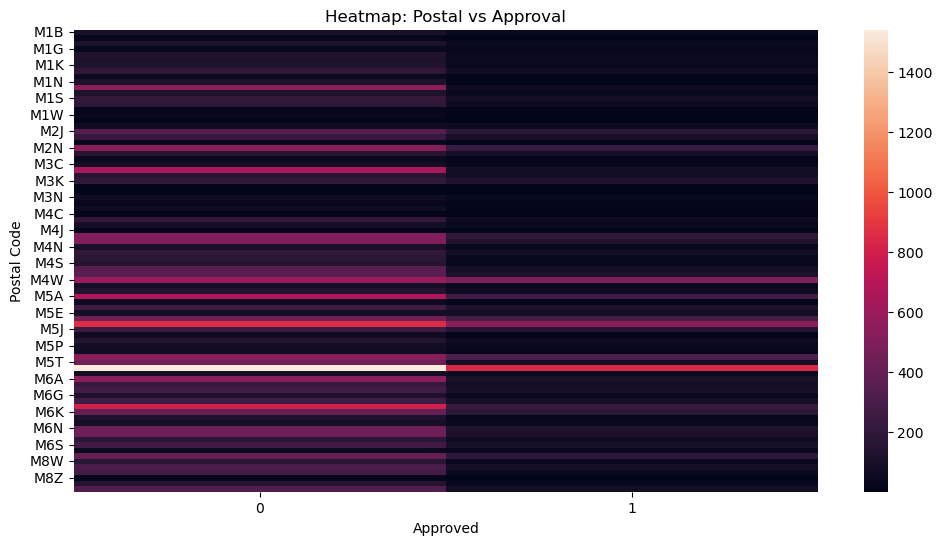

In [4]:
# Crear la columna approved
df_expanded = df_postal.loc[df_postal.index.repeat(df_postal["count_status"])].copy()
df_expanded["approved"] = (df_expanded["status_id"] == 32).astype(int)


# Crosstab
ct1 = pd.crosstab(df_expanded["postal"], df_expanded["approved"])

# Run chi-square
chi_square_test(ct1, "postal", "approved")

# Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(ct1, annot=False)
plt.title("Heatmap: Postal vs Approval")
plt.xlabel("Approved")
plt.ylabel("Postal Code")
plt.show()

## Hypothesis 2


=== Chi-Square Test: postal vs status_id ===
Chi-square value: 4756.674164708941
Degrees of freedom: 594
p-value: 0.0
➡ Conclusion: Reject H0 — There IS a significant relationship.



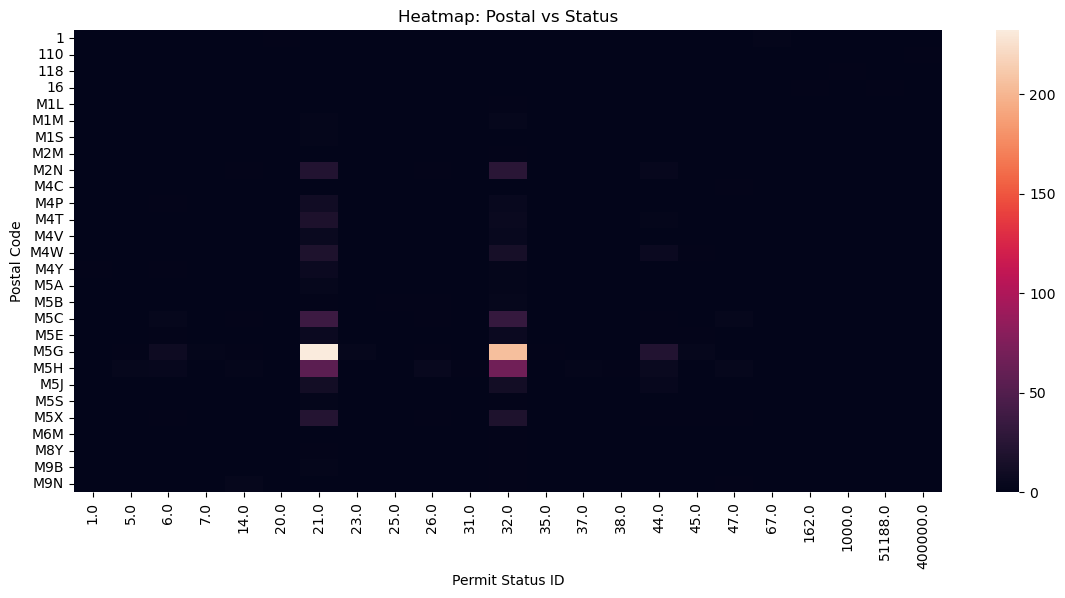

In [5]:
# Crear la columna approved
df["approved"] = (df["status_id"] == 32).astype(int)

# Crosstab
ct2 = pd.crosstab(df["postal"], df["status_id"])

# Run chi-square
chi_square_test(ct2, "postal", "status_id")

# Heatmap
plt.figure(figsize=(14,6))
sns.heatmap(ct2, annot=False)
plt.title("Heatmap: Postal vs Status")
plt.xlabel("Permit Status ID")
plt.ylabel("Postal Code")
plt.show()


## Hypothesis 3


=== Chi-Square Test: structure_type_id vs approved ===
Chi-square value: 68.57957300045224
Degrees of freedom: 41
p-value: 0.004429275662442323
➡ Conclusion: Reject H0 — There IS a significant relationship.



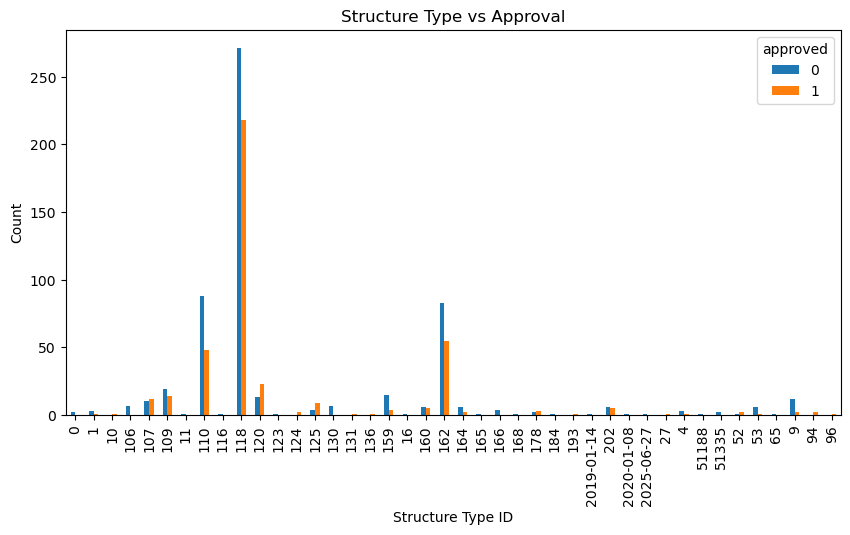

In [6]:
# Crosstab
ct3 = pd.crosstab(df["structure_type_id"], df["approved"])

# Run chi-square
chi_square_test(ct3, "structure_type_id", "approved")

# Barplot to visualize counts
ct3.plot(kind="bar", figsize=(10,5))
plt.title("Structure Type vs Approval")
plt.xlabel("Structure Type ID")
plt.ylabel("Count")
plt.show()


In [7]:
print("Hypothesis 1 Crosstab:")
display(ct1)

print("Hypothesis 2 Crosstab:")
display(ct2)

print("Hypothesis 3 Crosstab:")
display(ct3)


Hypothesis 1 Crosstab:


approved,0,1
postal,,
M1B,107,34
M1C,23,7
M1E,121,42
M1G,38,23
M1H,139,45
...,...,...
M8X,309,90
M8Y,279,40
M8Z,22,2


Hypothesis 2 Crosstab:


status_id,1.0,5.0,6.0,7.0,14.0,20.0,21.0,23.0,25.0,26.0,...,37.0,38.0,44.0,45.0,47.0,67.0,162.0,1000.0,51188.0,400000.0
postal,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
110,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
118,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
16,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
M1L,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
M1M,0,0,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
M1S,0,0,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
M2M,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
M2N,0,0,0,0,1,0,21,0,0,1,...,0,0,4,0,0,0,0,0,0,0


Hypothesis 3 Crosstab:


approved,0,1
structure_type_id,,
0,2,0
1,3,1
10,0,1
106,7,0
107,10,12
109,19,14
11,1,0
110,88,48
116,1,0
